In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import time

In [20]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [21]:
def build_lenet5():
    model = models.Sequential([
        layers.Conv2D(6, kernel_size=(5,5), activation='relu', input_shape=(32,32,3), padding='same'),
        layers.AveragePooling2D(),

        layers.Conv2D(16, kernel_size=(5,5), activation='relu'),
        layers.AveragePooling2D(),

        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [22]:
model = build_lenet5()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 32, 32, 6)         456       
                                                                 
 average_pooling2d_4 (Averag  (None, 16, 16, 6)        0         
 ePooling2D)                                                     
                                                                 
 conv2d_5 (Conv2D)           (None, 12, 12, 16)        2416      
                                                                 
 average_pooling2d_5 (Averag  (None, 6, 6, 16)         0         
 ePooling2D)                                                     
                                                                 
 flatten_2 (Flatten)         (None, 576)               0         
                                                                 
 dense_6 (Dense)             (None, 120)              

In [23]:
start_time = time.time()

history = model.fit(
    x_train, y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time: {training_time:.2f} seconds")

Epoch 1/25
704/704 [==============================] - 3s 3ms/step - loss: 1.6761 - accuracy: 0.3873 - val_loss: 1.4743 - val_accuracy: 0.4544
Epoch 2/25
704/704 [==============================] - 2s 3ms/step - loss: 1.3560 - accuracy: 0.5139 - val_loss: 1.3176 - val_accuracy: 0.5290
Epoch 3/25
704/704 [==============================] - 2s 3ms/step - loss: 1.2385 - accuracy: 0.5592 - val_loss: 1.2119 - val_accuracy: 0.5824
Epoch 4/25
704/704 [==============================] - 2s 3ms/step - loss: 1.1551 - accuracy: 0.5912 - val_loss: 1.1406 - val_accuracy: 0.5998
Epoch 5/25
704/704 [==============================] - 2s 3ms/step - loss: 1.0963 - accuracy: 0.6102 - val_loss: 1.1198 - val_accuracy: 0.6054
Epoch 6/25
704/704 [==============================] - 2s 3ms/step - loss: 1.0384 - accuracy: 0.6324 - val_loss: 1.0548 - val_accuracy: 0.6298
Epoch 7/25
704/704 [==============================] - 2s 3ms/step - loss: 0.9917 - accuracy: 0.6500 - val_loss: 1.0992 - val_accuracy: 0.6152
Epoch 

In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 64.84%
Test Loss: 1.2719


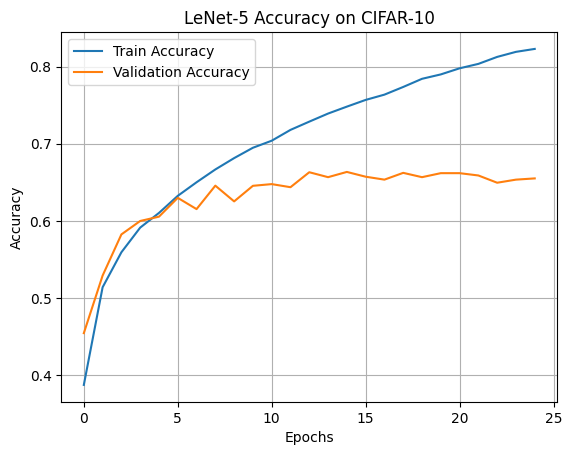

In [25]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('LeNet-5 Accuracy on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

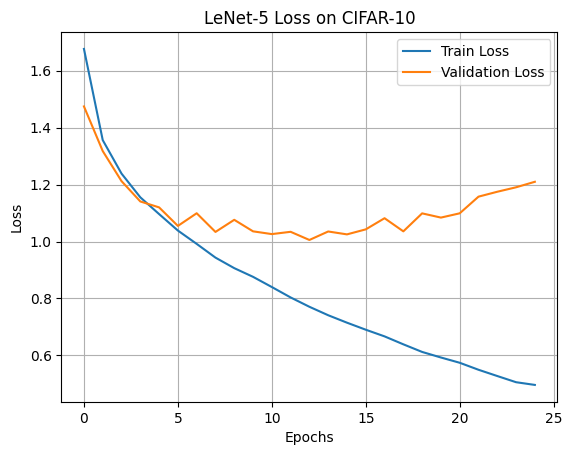

In [26]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LeNet-5 Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
total_params = model.count_params()
print(f"Total Parameters: {total_params:,}")

Total Parameters: 83,126
